# Consumer: Image Inference

Simulates an external consumer that:
1. Authenticates with MinIO and downloads the latest production model's
   `feature_names.txt` and `scaler.pkl`
2. Splits `feature_names` into **tag features** (LLM-scored) and
   **numeric features** (deterministic GLCM + statistics, prefixed
   `glcm_` / `stat_`)
3. Calls `/embed/image` with the image bytes and the tag list — the
   inference service is stateless; the caller owns the vocabulary
4. Assembles the full vector in `feature_names` order and scales it locally
5. Optionally downloads `ltn.h5` and runs prediction locally

## 1. Configuration

**Option A:** Upload a `.env` file — `MINIO_USER` and `MINIO_PASS` will be populated automatically.
**Option B:** Fill in the values manually in the cell below.

In [8]:
import ipywidgets as widgets
from IPython.display import display

MINIO_USER = "your_minio_username"
MINIO_PASS = "your_minio_password"


def _parse_env(content: str) -> dict:
    result = {}
    for line in content.splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        if "=" in line:
            key, _, value = line.partition("=")
            result[key.strip()] = value.strip().strip('"').strip("'")
    return result


def _on_env_upload(change):
    global MINIO_USER, MINIO_PASS
    value = change["new"]
    entries = value if isinstance(value, (list, tuple)) else value.values()
    for entry in entries:
        raw = entry["content"]
        text = bytes(raw).decode("utf-8") if not isinstance(raw, str) else raw
        env = _parse_env(text)
        if "MINIO_USER" in env:
            MINIO_USER = env["MINIO_USER"]
        if "MINIO_PASS" in env:
            MINIO_PASS = env["MINIO_PASS"]
        name = entry.get("name", entry.get("metadata", {}).get("name", ".env"))
        env_status.value = (
            f"<b style='color:green'>Loaded {name}</b> — "
            f"MINIO_USER=<code>{MINIO_USER}</code>, "
            f"MINIO_PASS=<code>{'*' * len(MINIO_PASS)}</code>"
        )


uploader = widgets.FileUpload(accept=".env", multiple=False, description="Upload .env")
env_status = widgets.HTML(value="<i style='color:grey'>No .env file uploaded yet.</i>")
uploader.observe(_on_env_upload, names="value")
display(widgets.VBox([uploader, env_status]))

In [9]:
import os

# --- Manual config (skip if you uploaded a .env above) ---
# MINIO_USER = "your_minio_username"
# MINIO_PASS = "your_minio_password"

MINIO_BUCKET  = "smart-healthcare-diabetes-models"
INFERENCE_URL = os.getenv("INFERENCE_API_URL", "http://localhost:8890")

print(f"Inference API : {INFERENCE_URL}")
print(f"MinIO bucket  : {MINIO_BUCKET}")

Inference API : http://localhost:8890
MinIO bucket  : smart-healthcare-diabetes-models


## 2. MinIO helpers (self-contained)

In [10]:
import requests

MINIO_HOST = "https://humaine-minio-api.euprojects.net"


def minio_auth(user, password):
    resp = requests.post(
        f"{MINIO_HOST}/auth/auth",
        data={"username": user, "password": password},
        headers={"Content-Type": "application/x-www-form-urlencoded"},
    )
    if resp.status_code == 200:
        return resp.json()["access_token"]
    raise RuntimeError(f"MinIO auth failed: {resp.status_code} {resp.text}")


def minio_read_json(token, bucket, object_name):
    resp = requests.get(
        f"{MINIO_HOST}/main_ops/download/{bucket}/{object_name}",
        headers={"Authorization": f"Bearer {token}", "accept": "application/json"},
    )
    return resp.json() if resp.status_code == 200 else None


def minio_download(token, bucket, object_name, file_path):
    resp = requests.get(
        f"{MINIO_HOST}/main_ops/download/{bucket}/{object_name}",
        headers={"Authorization": f"Bearer {token}", "accept": "application/json"},
    )
    if resp.status_code == 200:
        with open(file_path, "wb") as f:
            f.write(resp.content)
    else:
        raise RuntimeError(f"Download failed ({object_name}): {resp.status_code} {resp.text}")

## 3. Authenticate with MinIO

In [11]:
token = minio_auth(MINIO_USER, MINIO_PASS)
print("Authenticated successfully.")

Authenticated successfully.


## 4. Locate the latest production **image** model

Text and image models are published under type-specific subdirectories
(`published-models/{version}/text/...` and `.../images/...`). We filter the
index for `data_type == "image"` and `status == "production"` and pick the
most recent entry.

In [14]:
DATA_TYPE   = "image"
DATA_SUBDIR = "images"

index = minio_read_json(token, MINIO_BUCKET, "published-models/index.json") or []
promoted = [
    e for e in index
    if e.get("data_type") == DATA_TYPE
]
if not promoted:
    raise RuntimeError(f"No production-promoted {DATA_TYPE} model found in published-models/index.json.")

production_version = promoted[0]["version"]
prefix = f"published-models/{production_version}/{DATA_SUBDIR}"
print(f"Using production version: {production_version}")
print(f"Artifact prefix        : {prefix}")

Using production version: 20260413-170443
Artifact prefix        : published-models/20260413-170443/images


## 5. Download feature_names.txt and scaler.pkl, split into tags vs numeric

Numeric image features use the canonical prefixes `glcm_` and `stat_`.
Everything else is an LLM-scored tag.

In [15]:
import joblib

NUMERIC_PREFIXES = ("glcm_", "stat_")

local_features_path = f"./downloaded_feature_names_{production_version}.txt"
local_scaler_path   = f"./downloaded_scaler_{production_version}.pkl"

minio_download(token, MINIO_BUCKET, f"{prefix}/feature_names.txt", local_features_path)
minio_download(token, MINIO_BUCKET, f"{prefix}/scaler.pkl",        local_scaler_path)

with open(local_features_path) as f:
    feature_names = [ln.strip() for ln in f if ln.strip()]

tags          = [n for n in feature_names if not n.startswith(NUMERIC_PREFIXES)]
numeric_names = [n for n in feature_names if     n.startswith(NUMERIC_PREFIXES)]

scaler = joblib.load(local_scaler_path)

print(f"Total features : {len(feature_names)}")
print(f"  Tags         : {len(tags)}")
print(f"  Numeric      : {len(numeric_names)}")

Total features : 133
  Tags         : 113
  Numeric      : 20


## 6. Health check

In [16]:
resp = requests.get(f"{INFERENCE_URL}/health")
resp.raise_for_status()
print(resp.json())

{'status': 'ok'}


## 7. Load a test image

In [17]:
from IPython.display import Image as IPImage

IMAGE_PATH = None  # set to a local path to skip the uploader
_image_bytes = None

if IMAGE_PATH is None:
    img_uploader = widgets.FileUpload(accept="image/*", multiple=False)
    img_status   = widgets.HTML("<i style='color:grey'>No image uploaded yet.</i>")

    def _on_img_upload(change):
        global _image_bytes
        entries = change["new"]
        entries = entries if isinstance(entries, (list, tuple)) else list(entries.values())
        if entries:
            raw = entries[0]["content"]
            _image_bytes = bytes(raw) if not isinstance(raw, bytes) else raw
            img_status.value = f"<b style='color:green'>Loaded {len(_image_bytes):,} bytes</b>"

    img_uploader.observe(_on_img_upload, names="value")
    display(widgets.VBox([img_uploader, img_status]))
else:
    with open(IMAGE_PATH, "rb") as fh:
        _image_bytes = fh.read()
    print(f"Loaded {len(_image_bytes):,} bytes from {IMAGE_PATH}")

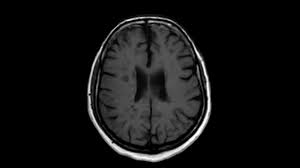

In [18]:
assert _image_bytes is not None, "Upload an image in the cell above first."
display(IPImage(data=_image_bytes, width=300))

## 8. Embed the image

POST multipart form: the image plus `tags` as a JSON-encoded list string.
Response carries `tag_features` (ordered to match `tags`) and
`numeric_features` (dict keyed by canonical name).

In [19]:
import json

resp = requests.post(
    f"{INFERENCE_URL}/embed/image",
    files={"image": ("image.jpg", _image_bytes, "image/jpeg")},
    data={"tags": json.dumps(tags)},
)
resp.raise_for_status()
embed = resp.json()

assert embed["tags"] == tags, "Service must echo tags in the order they were sent."
print(f"Tag features    : {len(embed['tag_features'])}")
print(f"Numeric features: {len(embed['numeric_features'])}")

Tag features    : 113
Numeric features: 20


## 9. Assemble the full vector in feature_names order, then scale

In [20]:
import numpy as np

tag_score   = dict(zip(embed["tags"], embed["tag_features"]))
numeric_val = embed["numeric_features"]

missing_numeric = [n for n in numeric_names if n not in numeric_val]
assert not missing_numeric, f"Service did not return {missing_numeric}"

raw_vector = np.array(
    [float(tag_score[n]) if n in tag_score else float(numeric_val[n])
     for n in feature_names],
    dtype=np.float32,
).reshape(1, -1)

scaled_vector = scaler.transform(raw_vector).astype(np.float32).flatten()
print("Full vector assembled in feature_names order and scaled.")

Full vector assembled in feature_names order and scaled.


## 10. Visualise tag and numeric panels separately

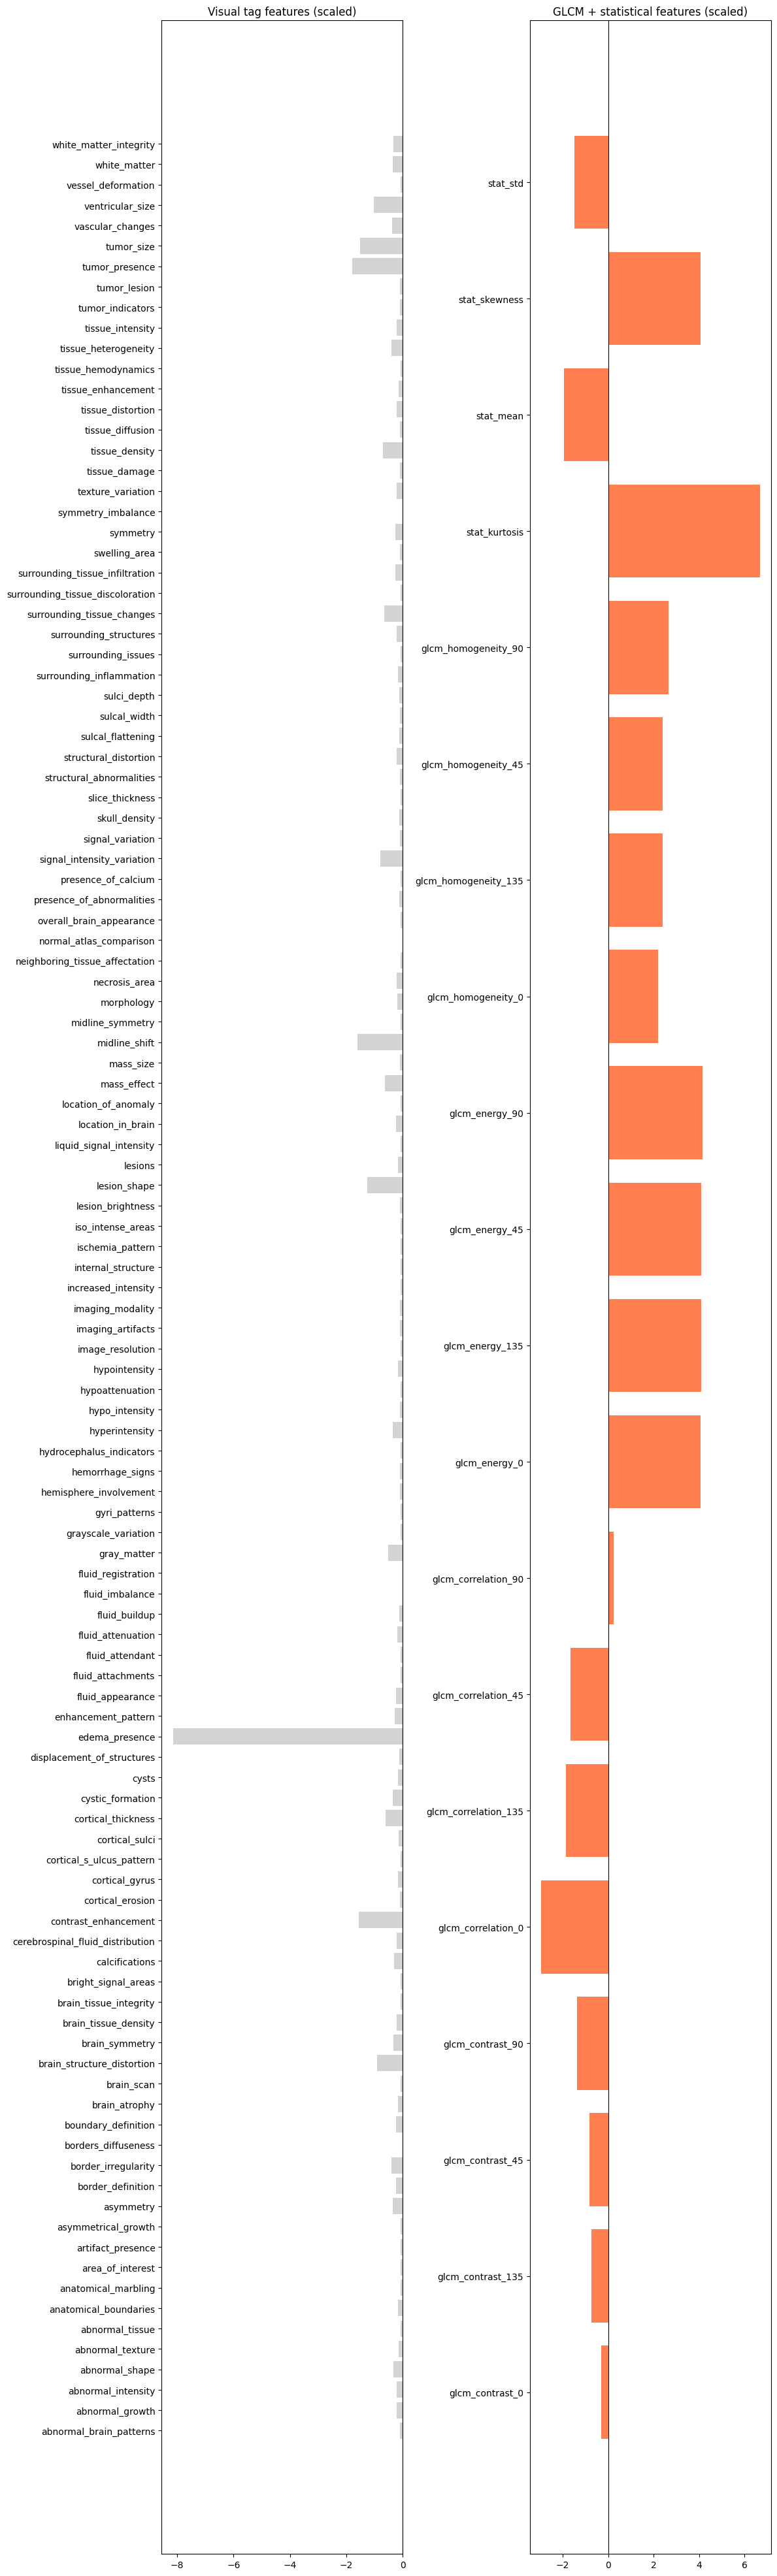

In [21]:
import matplotlib.pyplot as plt

feat_dict    = dict(zip(feature_names, scaled_vector))
tag_values   = [feat_dict[n] for n in tags]
num_values   = [feat_dict[n] for n in numeric_names]

n_panels = (1 if tags else 0) + (1 if numeric_names else 0)
fig, axes = plt.subplots(
    1, n_panels,
    figsize=(6 * n_panels, max(4, max(len(tags), len(numeric_names)) * 0.35)),
)
if n_panels == 1:
    axes = [axes]

panel = 0
if tags:
    ax = axes[panel]
    colors = ['steelblue' if v > 0 else 'lightgrey' for v in tag_values]
    ax.barh(tags, tag_values, color=colors)
    ax.set_title('Visual tag features (scaled)')
    ax.axvline(0, color='black', linewidth=0.8)
    panel += 1

if numeric_names:
    ax = axes[panel]
    ax.barh(numeric_names, num_values, color='coral')
    ax.set_title('GLCM + statistical features (scaled)')
    ax.axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

## 11. (Optional) Download the model and predict locally

In [22]:
import tensorflow as tf

local_model_path = f"./downloaded_ltn_{production_version}.h5"
minio_download(token, MINIO_BUCKET, f"{prefix}/ltn.h5", local_model_path)

model = tf.keras.models.load_model(local_model_path)
score = float(np.squeeze(model.predict(scaled_vector.reshape(1, -1), verbose=0)))
label = int(score > 0.5)

print(f"Score : {score:.4f}")
print(f"Label : {label}  ({'positive' if label == 1 else 'negative'} class)")

2026-04-13 20:09:07.331781: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-13 20:09:07.398768: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-13 20:09:07.418822: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-13 20:09:07.631414: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-13 20:09:09.079661: W tensorflow/compiler/tf2

Score : 0.1492
Label : 0  (negative class)


## 12. Cleanup (optional)

In [23]:
for path in [local_features_path, local_scaler_path, locals().get('local_model_path')]:
    if path and os.path.exists(path):
        os.remove(path)
        print(f"Removed: {path}")

Removed: ./downloaded_feature_names_20260413-170443.txt
Removed: ./downloaded_scaler_20260413-170443.pkl
Removed: ./downloaded_ltn_20260413-170443.h5
